## libs import

In [4]:
import pandas as pd
import sqlite3
from pandas.plotting import scatter_matrix

## connection

In [16]:
connection = sqlite3.connect('../data/checking-logs.sqlite')

## query for get avg_diff, pageviews and num_commits from pageviews and checker for users from test

In [36]:
query = """
SELECT
    t.uid,
    ROUND(AVG(JULIANDAY(DATETIME(t.first_commit_ts)) - JULIANDAY(DATETIME(d.deadlines, 'unixepoch')))*24,3) AS avg_diff,
    pageviews,
    num_commits
FROM
    test t
JOIN
    deadlines d ON t.labname = d.labs
LEFT JOIN (SELECT uid, count(*) AS pageviews
           FROM pageviews
           GROUP BY uid) AS views ON t.uid=views.uid
LEFT JOIN (SELECT uid, count(*) AS num_commits
           FROM checker
           WHERE labname != 'project1'
           GROUP BY uid) AS ch ON t.uid=ch.uid
WHERE labname != 'project1'
GROUP BY t.uid
"""

df = pd.read_sql_query(query, connection)

In [37]:
df

,uid,avg_diff,pageviews,num_commits
0,user_1,-65.120,28,62
1,user_10,-75.242,89,20
2,user_14,-159.569,143,61
3,user_17,-62.208,47,51
4,user_18,-6.368,3,5
5,user_19,-99.440,16,118
6,user_21,-96.111,10,65
7,user_25,-93.475,179,79
8,user_28,-86.794,149,60
9,user_3,-105.738,317,18


## Plot. Scatter for avg_diff, pageviews and num_commits

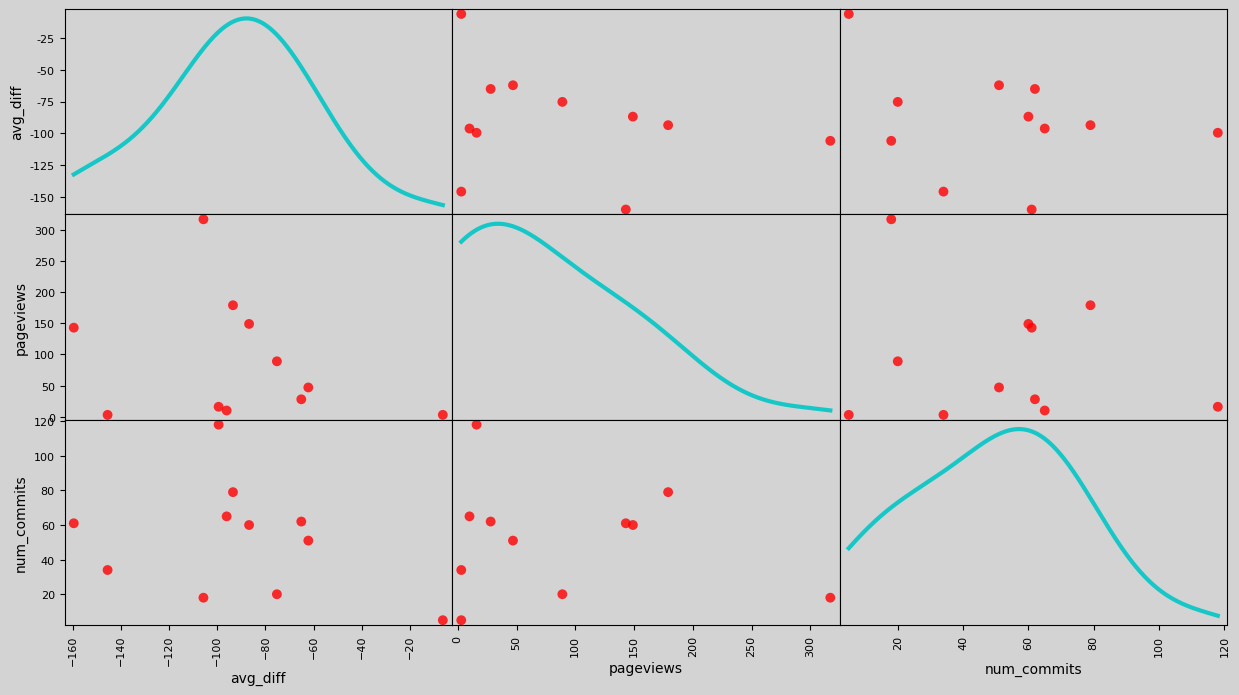

In [65]:
# Создание scatter matrix
axes = scatter_matrix(df.drop(columns='uid'), alpha=0.8, figsize=(15, 8), diagonal='kde', color = ['red']*11, s=200)
fig = axes[0, 0].get_figure()
fig.patch.set_facecolor('lightgrey')
for ax in axes.flatten():
    ax.set_facecolor('lightgrey')
for i in range(len(axes)):
    # Уходим в диагональные графики
    for line in axes[i, i].lines:  # Получаем линии на диагонали
        line.set_color('#16c7c7')
        line.set_linewidth(3) 

## Answer for questions:

### “Can we say that if a user has a low number of pageviews then they likely have a low number of commits?” 
### The answer: yes
### “Can we say that if a user has a low number of pageviews then they likely have a small average difference between the first commit and the lab deadline?” 
### The answer: no
### “Can we say that there are many users with a low number of commits and a few with a high number of commits”? 
### The answer: yes
### “Can we say that there are many users with a small average difference and a few with a large average difference”? 
### The answer: no

## connection close

In [68]:
connection.close()